In [9]:
!pip install b3alien

In [10]:
import geopandas as gpd
import pandas as pd
import xarray as xr
import sparse
import dask.array as da
import numpy as np

from pyproj import Proj, Transformer
from shapely.geometry import mapping
from shapely.geometry import Polygon
import matplotlib.pyplot as plt

%matplotlib inline

In [13]:
# Load the GRIIS checklist

checklist_path = "../data/dwca-unified-checklist-v1.15/"
distribution = checklist_path + "distribution.txt"

df_cl = pd.read_csv(distribution, sep='\t', low_memory=False)

In [15]:
# Specific issue due to the Belgian checklist
df_cl["speciesKey"] = df_cl["id"].str.rsplit("/", n=1).str[-1].astype("int64")

In [17]:
df_cl.head()

,id,locationID,locality,countryCode,occurrenceStatus,establishmentMeans,degreeOfEstablishment,pathway,eventDate,source,speciesKey
0,https://www.gbif.org/species/1002621,ISO_3166:BE,Belgium,BE,present,introduced,NaN,NaN,1974/1974,https://www.gbif.org/species/157131084: Kerate...,1002621
1,https://www.gbif.org/species/1003567,ISO_3166:BE,Belgium,BE,present,introduced,NaN,NaN,2014/2022,https://www.gbif.org/species/206111211: Pectin...,1003567
2,https://www.gbif.org/species/1003567,ISO_3166:BE-VLG,Flemish Region,BE,present,introduced,NaN,NaN,2014/2022,https://www.gbif.org/species/206111211: Pectin...,1003567
3,https://www.gbif.org/species/10071055,ISO_3166:BE,Belgium,BE,present,introduced,casual,horticulture,1934/2018,https://www.gbif.org/species/141265441: Sorbus...,10071055
4,https://www.gbif.org/species/10071055,ISO_3166:BE-BRU,Brussels-Capital Region,BE,present,introduced,NaN,NaN,NaN,https://www.gbif.org/species/141265441: Sorbus...,10071055


In [19]:
# 1. Filter rows where locality == 'Belgium' and eventDate is not missing
df = df_cl[df_cl["locality"] == "Belgium"].copy()
df = df[df["eventDate"].notna()]

# 2. Split eventDate into intro and outro (assuming 'YYYY/MM' or 'YYYY/MM/YYYY/MM')
def split_event_date(x):
    if isinstance(x, str):
        parts = x.strip().split('/')
        if len(parts) == 2:
            intro = parts[0]
            outro = parts[1]
        else:
            intro = outro = np.nan
        return pd.Series([intro, outro])
    else:
        return pd.Series([np.nan, np.nan])

df[["introDate", "outroDate"]] = df["eventDate"].apply(split_event_date)

df["introDate"] = pd.to_datetime(df["introDate"], format="%Y", errors="coerce")
df["outroDate"] = pd.to_datetime(df["outroDate"], format="%Y", errors="coerce")


# 3. Clean rows with missing introDate
df_intro = df.dropna(subset=["introDate"]).copy()

# 4. Group by introDate and count species
in_species = (
    df_intro.groupby("introDate", sort=True)["id"]
    .count()
    .reset_index(name="nspec")
)

# 5. Cumulative sum
in_species["cumn"] = in_species["nspec"].cumsum()

# 6. Clean outro side and count outgoing species
df_outro = df.dropna(subset=["outroDate"]).copy()

out_species = (
    df_outro.groupby("outroDate", sort=True)["id"]
    .count()
    .reset_index(name="nspeco")
)

# 7. Merge intro and outro on date
n_species = pd.merge(in_species, out_species, how="outer", left_on="introDate", right_on="outroDate")

# 8. Replace NaNs with 0
n_species["nspec"] = n_species["nspec"].fillna(0).astype(int)
n_species["nspeco"] = n_species["nspeco"].fillna(0).astype(int)

# 9. Net species present at each time step
n_species["total"] = n_species["nspec"] - n_species["nspeco"]

# 10. Final frame with total species over time
tot_species = n_species[["introDate", "total"]].copy()

# 11. Optional: sort and compute cumulative total over time
tot_species = tot_species.sort_values("introDate")
tot_species["cumulative_total"] = tot_species["total"].cumsum()

In [21]:
in_species

,introDate,nspec,cumn
0,1680-01-01,1,1
1,1700-01-01,2,3
2,1701-01-01,1,4
3,1711-01-01,1,5
4,1730-01-01,1,6
...,...,...,...
216,2021-01-01,90,3830
217,2022-01-01,106,3936
218,2023-01-01,47,3983
219,2024-01-01,2,3985


In [23]:
#save the table
in_species.to_csv("./output/total_newly_established_species_per_year_raw_data.csv", index=False)

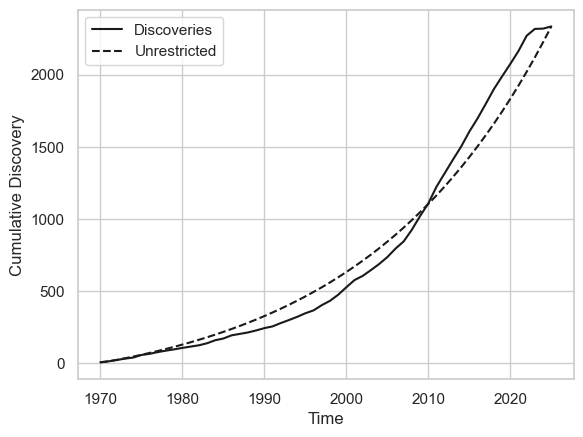

In [25]:
from b3alien import b3cube
from b3alien import griis
from b3alien import simulation

%matplotlib inline

def filter_time_window(df, start_year, end_year):
    """Filter time and rate based on year window."""
    filtered = df[(df["year"] >= start_year) & (df["year"] <= end_year)].reset_index(drop=True)
    return filtered["year"], filtered["rate"]


in_species["time"] = pd.to_datetime(in_species["introDate"])
in_species["cumulative_species"] = in_species["cumn"]

time, rate = b3cube.calculate_rate(in_species)


df = pd.DataFrame({
    "year": time,
    "rate": rate
})


# Here you can change the time period of the calculation
time, rate = filter_time_window(df, 1970, 2025)

C1, vec1 = simulation.simulate_solow_costello_scipy(time, rate, vis=True)

Bootstrapping: 100%|█████████████████████████████████████████████████████████████████| 200/200 [07:36<00:00,  2.28s/it]
C:\Users\jasmijn_hillaert\AppData\Local\anaconda3\Lib\site-packages\b3alien\simulation\simulation.py:466: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  plt.tight_layout()
C:\Users\jasmijn_hillaert\AppData\Local\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


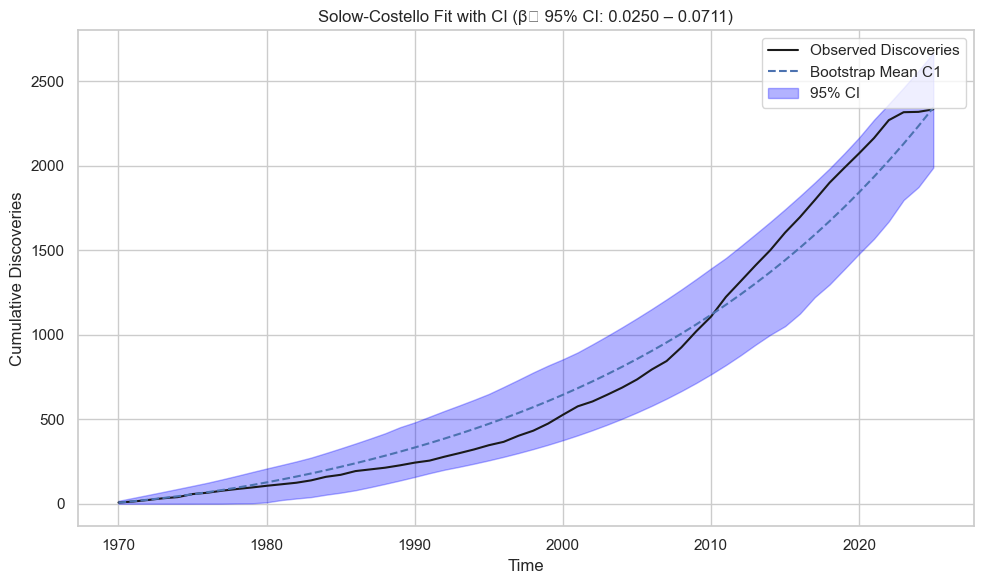

In [27]:
results = simulation.parallel_bootstrap_solow_costello(time, rate, n_iterations=200)

simulation.plot_with_confidence(time, rate, results)



In [29]:
rates_results = simulation.run_bootstrap_analysis(time, rate, n_iterations=200)

Starting 200 bootstrap iterations...

FITTING PARAMETERS RESULTS
Parameter vec1[1]: 0.024161 ± 0.275220



In [36]:
print(rates_results.tail())

    Year  Annual_Rate  Annual_Rate_Error  Cumulative_Value  Cumulative_Error  \
51  2021    91.179375          10.997992       1925.109383        188.967385   
52  2022    95.304100          12.415794       2020.413482        188.817586   
53  2023    99.629922          14.003649       2120.043404        189.005602   
54  2024   104.167463          15.773303       2224.210866        189.849512   
55  2025   108.582278          18.095469       2332.793144        191.695862   

    Lower_CI_95  Upper_CI_95  
51    69.623312   112.735439  
52    70.969143   119.639056  
53    72.182769   127.077074  
54    73.251790   135.083135  
55    73.115159   144.049396  


In [38]:
rates_results.to_csv("./output/estimated_rates_solow_costello_effective_annual_rates_no_filtering.csv", index=False)

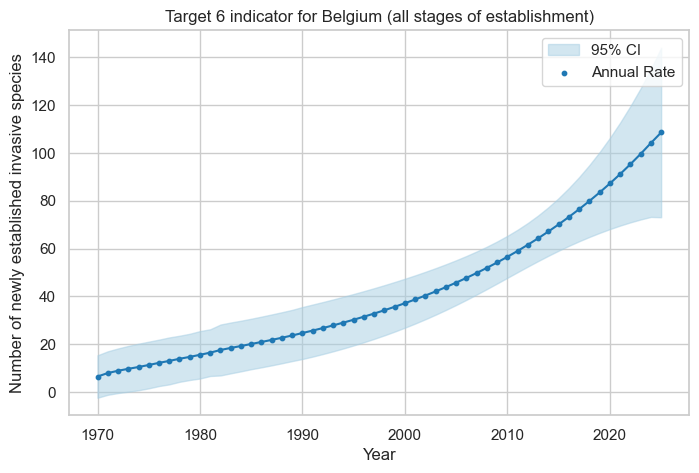

In [49]:
#draw plot of Target 6 indicator
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(8,5))

df = rates_results
# Plot CI band
plt.fill_between(df['Year'], df['Lower_CI_95'], df['Upper_CI_95'], color='#a6cee3', alpha=0.5, label='95% CI')

# Plot punten van Annual_Rate
plt.scatter(df['Year'], df['Annual_Rate'], color='#1f78b4', s=10, label='Annual Rate')

# Verbinding van punten (lineaire)
plt.plot(df['Year'], df['Annual_Rate'], color='#1f78b4')

# Optioneel: smooth curve
# sns.lineplot(x='ear', y='Annual_Rate', data=df, color='blue', label='Smoothed Curve')

plt.xlabel('Year')
plt.ylabel('Number of newly established invasive species')
plt.title('Target 6 indicator for Belgium (all stages of establishment)')
plt.legend()
#plt.show()
#print('Finished')
plt.savefig('./output/Figure_target6_indicator_no_filtering.png', dpi=200)

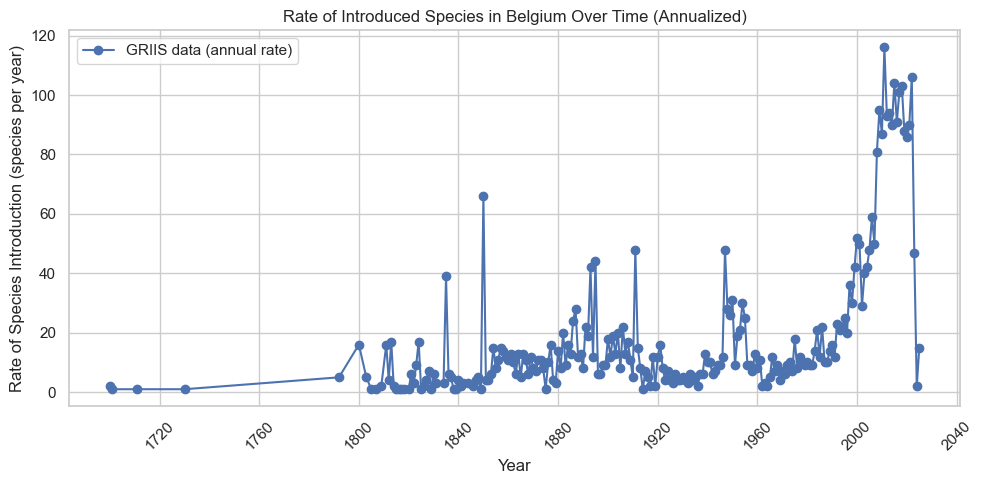

In [44]:
# --- Processing GRIIS data (Annual) ---
in_species["introDate"] = pd.to_datetime(in_species["introDate"])
in_species_rate = in_species.sort_values(by="introDate").copy()
in_species_rate["rate_per_year"] = in_species_rate["cumn"].diff()


# --- Plotting the rate of species (per year) ---
plt.figure(figsize=(10, 5))
#plt.plot(pd.to_datetime(annual_time_gbif, format='%Y'), annual_rate_gbif_series, marker="x", label="GBIF data (approx. annual rate)")
plt.plot(in_species_rate["introDate"][1:], in_species_rate["rate_per_year"][1:], marker="o", label="GRIIS data (annual rate)")
plt.title("Rate of Introduced Species in Belgium Over Time (Annualized)")
plt.xlabel("Year")
plt.ylabel("Rate of Species Introduction (species per year)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.savefig("./output/Raw_data_new_species_per_year_figure.png")